### Métodos usados

In [ ]:



def truncar(numero, decimales):
    """
    Trunca un número a un número específico de decimales.
    
    :param numero: El número a truncar
    :param decimales: Cuántos decimales mantener
    :return: Número truncado
    Ejemplo: original=0.335 → truncado=0.33 (2 decimales)
    """
    factor = 10 ** decimales
    return int(numero * factor) / factor


#función eplines cúbicos
def spline_cubico_natural(x, y, decimales = None):
    """
    Calcula los coeficientes del spline cúbico natural para puntos (x_i, y_i).
    
    :param x: lista de valores x (n+1 puntos)
    :param y: lista de valores y correspondientes
    :return: listas a, b, c, d para cada tramo j = 0, ..., n-1
    """
    n = len(x) - 1
    h = [x[i+1] - x[i] for i in range(n)]
    
    # Paso 2: calcular alpha
    alpha = [0] * (n+1)
    for i in range(1, n):
        alpha[i] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    
    # Paso 3: inicialización
    l = [1] + [0] * n
    mu = [0] * (n+1)
    z = [0] * (n+1)
    
    # Paso 4: resolver sistema tridiagonal
    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
    
    # Paso 5: condiciones naturales
    l[n] = 1
    z[n] = 0
    c = [0] * (n+1)
    
    # Paso 6: retro-substitución
    b = [0] * n
    d = [0] * n
    a = [y[j] for j in range(n)]
    
    for j in reversed(range(n)):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
    
    #Paso 7: truncar decimales
    if decimales is not None:
        a = [truncar(val, decimales) for val in a]
        b = [truncar(val, decimales) for val in b]
        c = [truncar(val, decimales) for val in c[:n]]
        d = [truncar(val, decimales) for val in d]


    return a, b, c[:n], d


## datos filtrados y promediados 


In [46]:
## cargar data set y filtar por uso de aire /no
import pandas as pd
datos = pd.read_csv('../Dataset/household_energy_consumption.csv')
#Asegurar que la columna de fecha esté en formato datetime
datos['Date'] = pd.to_datetime(datos['Date'])


#filtar datos por uso de aire acondicionado
datos_aire = datos[datos['Has_AC'] == 'Yes']
datos_aire.to_csv('../Dataset/datos_aire.csv', index=False)

#filtrar datos por no uso de aire acondicionado
datos_no_aire = datos[datos['Has_AC'] == 'No']
datos_no_aire.to_csv('../Dataset/datos_no_aire.csv', index=False)

promedio_aire = (
    datos_aire.groupby('Date').agg({
        'Energy_Consumption_kWh': 'mean',
        'Avg_Temperature_C': 'mean',
    }).reset_index()
)

promedio_no_aire = (
    datos_no_aire.groupby('Date').agg({
        'Energy_Consumption_kWh': 'mean',
        'Avg_Temperature_C': 'mean',
    }).reset_index()
)


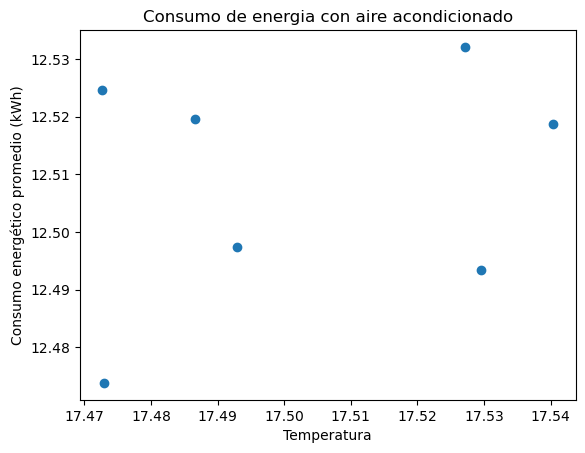

In [47]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(promedio_aire['Avg_Temperature_C'], promedio_aire['Energy_Consumption_kWh'])
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético promedio (kWh)")
plt.title("Consumo de energia con aire acondicionado")
plt.show()

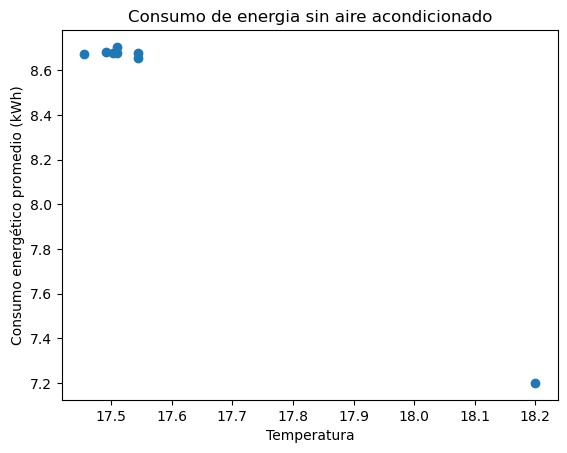

In [48]:
plt.figure()
plt.scatter(promedio_no_aire['Avg_Temperature_C'], promedio_no_aire['Energy_Consumption_kWh'])
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético promedio (kWh)")
plt.title("Consumo de energia sin aire acondicionado")
plt.show()

In [49]:
puntos_aire_x = promedio_aire['Avg_Temperature_C'].tolist()
puntos_aire_y = promedio_aire['Energy_Consumption_kWh'].tolist()
puntos_no_aire_x = promedio_no_aire['Avg_Temperature_C'].tolist()
puntos_no_aire_y = promedio_no_aire['Energy_Consumption_kWh'].tolist() 
# Unir x e y
puntos_aire = list(zip(puntos_aire_x, puntos_aire_y))
puntos_no_aire = list(zip(puntos_no_aire_x, puntos_no_aire_y))

# Ordenar por x
puntos_aire.sort(key=lambda p: p[0])
puntos_no_aire.sort(key=lambda p: p[0])

# Separar nuevamente
puntos_aire_x = [p[0] for p in puntos_aire]
puntos_aire_y = [p[1] for p in puntos_aire]


puntos_no_aire_x = [p[0] for p in puntos_no_aire]
puntos_no_aire_y = [p[1] for p in puntos_no_aire]

In [50]:
a1, b1, c1, d1 = spline_cubico_natural(puntos_aire_x, puntos_aire_y, decimales=4)
a2, b2, c2, d2 = spline_cubico_natural(puntos_no_aire_x, puntos_no_aire_y, decimales=4)

# Mostrar resultados
for j in range(len(a1)):
    print(f"Tramo {j}: S(x) = {a1[j]} + {b1[j]}*(x - {puntos_aire_x[j]}) + {c1[j]}*(x - {puntos_aire_x[j]})**2 + {d1[j]}*(x - {puntos_aire_x[j]})**3")

for j in range(len(a2)):
    print(f"Tramo {j}: S(x) = {a2[j]} + {b2[j]}*(x - {puntos_no_aire_x[j]}) + {c2[j]}*(x - {puntos_no_aire_x[j]})**2 + {d2[j]}*(x - {puntos_no_aire_x[j]})**3") 



Tramo 0: S(x) = 12.5247 + -233.2624*(x - 17.472687224669603) + 0.0*(x - 17.472687224669603)**2 + 46632026.6284*(x - 17.472687224669603)**3
Tramo 1: S(x) = 12.4738 + -226.4751*(x - 17.472907488986785) + 30814.1145*(x - 17.472907488986785)**2 + -1024830.5837*(x - 17.472907488986785)**3
Tramo 2: S(x) = 12.5195 + 40.699*(x - 17.48661107614852) + -11317.4511*(x - 17.48661107614852)**2 + 685919.1279*(x - 17.48661107614852)**3
Tramo 3: S(x) = 12.4974 + -20.0918*(x - 17.49295154185022) + 1729.6889*(x - 17.49295154185022)**2 + -32505.5926*(x - 17.49295154185022)**3
Tramo 4: S(x) = 12.5321 + -16.0556*(x - 17.52721837633732) + -1611.9023*(x - 17.52721837633732)**2 + 566190.2383*(x - 17.52721837633732)**3
Tramo 5: S(x) = 12.4933 + -14.426*(x - 17.529531151667715) + 2316.51*(x - 17.529531151667715)**2 + -71129.1697*(x - 17.529531151667715)**3
Tramo 0: S(x) = 8.6742 + -23.6811*(x - 17.45588371019843) + 0.0*(x - 17.45588371019843)**2 + 18263.5557*(x - 17.45588371019843)**3
Tramo 1: S(x) = 8.6816 + 47

In [51]:
def evaluar_spline(x_eval, x, a, b, c, d):
    """
    Evalúa el spline cúbico en los puntos x_eval
    """
    y_eval = []

    for xv in x_eval:
        # buscar el tramo correcto
        for j in range(len(a)):
            if x[j] <= xv <= x[j+1]:
                dx = xv - x[j]
                yv = a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
                y_eval.append(yv)
                break

    return y_eval


In [52]:
import numpy as np

x_spline_aire = []
for j in range(len(a1)):
    x_tramo = np.linspace(puntos_aire_x[j], puntos_aire_x[j+1], 50)
    x_spline_aire.extend(x_tramo)

y_spline_aire = evaluar_spline(x_spline_aire, puntos_aire_x, a1, b1, c1, d1)

x_spline_no_aire = []
for j in range(len(a2)):
    x_tramo = np.linspace(puntos_no_aire_x[j], puntos_no_aire_x[j+1], 50)
    x_spline_no_aire.extend(x_tramo)
y_spline_no_aire = evaluar_spline(x_spline_no_aire, puntos_no_aire_x, a2, b2, c2, d2)



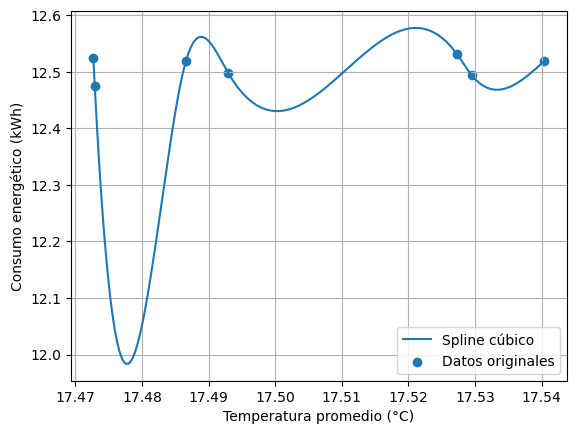

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(x_spline_aire, y_spline_aire, label="Spline cúbico")
plt.scatter(puntos_aire_x, puntos_aire_y, label="Datos originales")
plt.xlabel("Temperatura promedio (°C)")
plt.ylabel("Consumo energético (kWh)")
plt.legend()
plt.grid(True)
plt.show()


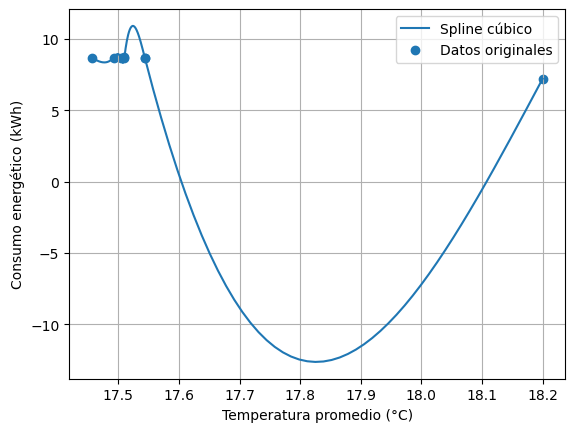

In [54]:
plt.figure()
plt.plot(x_spline_no_aire, y_spline_no_aire, label="Spline cúbico")
plt.scatter(puntos_no_aire_x, puntos_no_aire_y, label="Datos originales")
plt.xlabel("Temperatura promedio (°C)")
plt.ylabel("Consumo energético (kWh)")
plt.legend()
plt.grid(True)
plt.show()